tol 0.001 Jacobi iters: 10 GS iters: 7


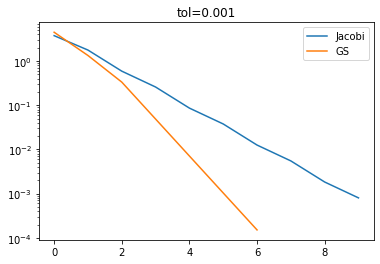

tol 1e-06 Jacobi iters: 17 GS iters: 10


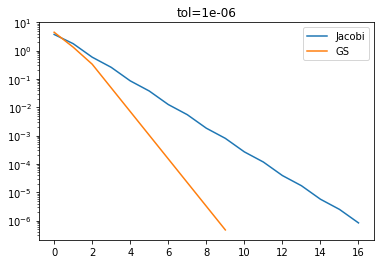

tol 1e-09 Jacobi iters: 25 GS iters: 14


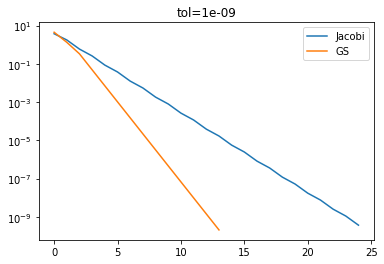

In [2]:
import numpy as np, matplotlib.pyplot as plt

def jacobi(A,b,x,tol):
    errs=[]
    while True:
        x_new=(b-(A-np.diag(np.diag(A)))@x)/np.diag(A)
        err=np.linalg.norm(x_new-x,np.inf)
        errs.append(err)
        if err<tol: return x_new,len(errs),errs
        x=x_new

def gs(A,b,x,tol):
    errs=[]
    while True:
        x_old=x.copy()
        for i in range(len(b)):
            x[i]=(b[i]-A[i,:i]@x[:i]-A[i,i+1:]@x_old[i+1:])/A[i,i]
        err=np.linalg.norm(x-x_old,np.inf)
        errs.append(err)
        if err<tol: return x,len(errs),errs

A=np.array([[4,-1,0],[-1,4,-1],[0,-1,3]],float)
b=np.array([15,10,10],float)
x0=np.array([0,0,0],float)

for tol in [1e-3,1e-6,1e-9]:
    xj,ij,ej=jacobi(A,b,x0.copy(),tol)
    xg,ig,eg=gs(A,b,x0.copy(),tol)
    print("tol",tol,"Jacobi iters:",ij,"GS iters:",ig)
    plt.semilogy(ej,label="Jacobi")
    plt.semilogy(eg,label="GS")
    plt.title("tol="+str(tol))
    plt.legend()
    plt.show()

As the tolerance decreases the number of iterations required for convergence increases for both. This is the case because tolerance directly correlates to the error allowed so the decreased error allowed requires the solution to be as accurate as stated which requires more iterations.